In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
import random
import numpy as np
from utils import plot_tsne
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
latent_dim = 128
batch_size = 128
learning_rate = 1e-3
# Early stopping parameters
patience = 10
best_val_loss = float('inf')
patience_counter = 0
checkpoint_dir = 'checkpoints'
patience_classifier = 5
best_val_loss_classifier = float('inf')
patience_counter_classifier = 0
os.makedirs(checkpoint_dir, exist_ok=True)

# Configuration
config = {
    'MNIST': {
        'input_channels': 1,
        'input_size': 28,
        'num_classes': 10,
        'transform': transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ]),
        'mean': (0.1307,),
        'std': (0.3081,),
        'ae_epochs': 10,
        'cls_epochs': 20
    },
    'CIFAR10': {
        'input_channels': 3,
        'input_size': 32,
        'num_classes': 10,
        'transform': transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ]),
        'mean': (0.5, 0.5, 0.5),
        'std': (0.5, 0.5, 0.5),
        'ae_epochs': 30,
        'cls_epochs': 25
    }
}
m_cfg = config['MNIST']
c_cfg = config['CIFAR10']

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

In [2]:

class Autoencoder(nn.Module): # Gal
    def __init__(self, input_channels, input_size):
        super().__init__()
        self.input_dim = input_channels * input_size ** 2
        self.input_channels = input_channels
        self.input_size = input_size
        self.encoder = nn.Sequential(
            nn.Linear(self.input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, self.input_dim)
        )

    def forward(self, x):
        x = x.view(-1, self.input_dim)
        x = self.encoder(x)
        x = self.decoder(x)
        return x.view(-1, self.input_channels, self.input_size, self.input_size)   



In [3]:
class Classifier(nn.Module):
    def __init__(self, encoder, input_channels, input_size, num_classes):
        super(Classifier, self).__init__()
        self.encoder = encoder
        self.input_channels = input_channels
        self.input_size = input_size
        self.input_dim = input_channels * input_size ** 2
        
        # From your autoencoder, we know the latent dimension is 128
        latent_dim = 128
        
        # Classifier layers
        fc_dim = 2048
        self.fc1 = nn.Linear(latent_dim, fc_dim)
        self.bn1 = nn.BatchNorm1d(fc_dim)
        self.fc2 = nn.Linear(fc_dim, fc_dim)
        self.bn2 = nn.BatchNorm1d(fc_dim)
        self.fc3 = nn.Linear(fc_dim, num_classes)
        self.dropout = nn.Dropout(0.65)

    def forward(self, x):
        # Flatten the input just like in the autoencoder
        x = x.view(-1, self.input_dim)
        
        # Pass through encoder to get latent representation
        x = self.encoder(x)
        
        # Apply classifier layers
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

In [4]:
autoencoder = Autoencoder(input_channels=c_cfg['input_channels'], input_size=c_cfg['input_size']).to(device)
classifier = Classifier(autoencoder.encoder, input_channels=c_cfg['input_channels'], input_size=c_cfg['input_size'], 
                        num_classes=c_cfg['num_classes']).to(device)

print(autoencoder)
print(classifier)


Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=3072, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=3072, bias=True)
  )
)
Classifier(
  (encoder): Sequential(
    (0): Linear(in_features=3072, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
  )
  (fc1): Linear(in_features=128, out_features=2048, bias=True)
  (bn1): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=2048, out_features=2048, bias=True)
  (bn2): Ba

In [16]:
from torch.utils.data import Dataset


class MemoryDataset(Dataset):
    def __init__(self, dataset):
        self.data = [dataset[i] for i in range(len(dataset))]
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]


def load_dataset(dataset_name):
    cfg = config[dataset_name]
    if dataset_name == 'MNIST':
        train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=cfg['transform'])
        train_dataset = MemoryDataset(train_dataset)
        test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=cfg['transform'])
        test_dataset = MemoryDataset(test_dataset)
    elif dataset_name == 'CIFAR10':
        train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=cfg['transform'])
        train_dataset = MemoryDataset(train_dataset)
        test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=cfg['transform'])
        test_dataset = MemoryDataset(test_dataset)
    
    # Split train into train and validation
    train_size = len(train_dataset) - 10000
    train_dataset, val_dataset = random_split(train_dataset, [train_size, 10000])
    
    return train_dataset, val_dataset, test_dataset

def create_data_loaders(train_dataset, val_dataset, test_dataset, batch_size):
    return (
        DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
        DataLoader(val_dataset, batch_size=batch_size, shuffle=False),
        DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    )

def plot_losses(train_losses, val_losses, title, objective='loss'):
    plt.figure()
    plt.plot(train_losses, label=f'Train {objective}')
    plt.plot(val_losses, label=f'Validation {objective}')
    plt.xlabel('Epoch')
    plt.ylabel(f'{objective.capitalize()}')
    plt.title(title)
    plt.legend()
    plt.show()


In [ ]:
def train_autoencoder(model, train_loader, val_loader, device, num_epochs, dataset_name):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    best_val_loss = float('inf')
    patience_counter = 0
    checkpoint_dir = f'checkpoints/{dataset_name}'
    os.makedirs(checkpoint_dir, exist_ok=True)
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for images, _ in tqdm(train_loader, desc=f"AE Epoch {epoch+1}"):
            images = images.to(device)
            outputs = model(images)
            loss = criterion(outputs, images)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        train_losses.append(train_loss/len(train_loader))
        val_loss = evaluate(model, val_loader, device, criterion)
        val_losses.append(val_loss)
        print(f'AE Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss:.4f}')

        # Early stopping and checkpoint logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f'{checkpoint_dir}/ae_best.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered")
                break
        
        
        if isinstance(model, Autoencoder):
            with torch.no_grad():
                dataiter = iter(val_loader)
                images, _ = next(dataiter)
                images = images.to(device)
                outputs = model(images)
                images = images.cpu()
                outputs = outputs.cpu()
                
                # Get image dimensions automatically
                batch_size, channels, height, width = images.shape
                random_indices = torch.randperm(batch_size)[:5]

                # Denormalize images using the config values
                def denormalize(x, dataset_name):
                    mean = torch.tensor(config[dataset_name]['mean']).view(channels, 1, 1)
                    std = torch.tensor(config[dataset_name]['std']).view(channels, 1, 1)
                    return x * std + mean
                
                images_display = denormalize(images, dataset_name)
                outputs_display = denormalize(outputs, dataset_name)
                
                fig, axes = plt.subplots(2, 5, figsize=(12, 4))
                for i in range(5):
                    idx = random_indices[i]
                    if channels == 1:
                        axes[0, i].imshow(images_display[idx].squeeze(), cmap='gray')
                        axes[0, i].axis('off')
                        axes[1, i].imshow(outputs_display[idx].squeeze(), cmap='gray')
                        axes[1, i].axis('off')
                    else:
                        axes[0, i].imshow(images_display[idx].permute(1, 2, 0).clamp(0, 1))
                        axes[0, i].axis('off')
                        axes[1, i].imshow(outputs_display[idx].permute(1, 2, 0).clamp(0, 1))
                        axes[1, i].axis('off')
                
                axes[0, 0].set_title('Original', size=14)
                axes[1, 0].set_title('Reconstructed', size=14)
                plt.tight_layout()
                plt.show()
        
    plot_losses(train_losses, val_losses, 'Autoencoder Losses')

    return model

def train_classifier(model, train_loader, val_loader, device, num_epochs, dataset_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True)
    best_val_acc = 0
    patience_counter = 0
    checkpoint_dir = f'checkpoints/{dataset_name}'
    os.makedirs(checkpoint_dir, exist_ok=True)
    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    for epoch in range(num_epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in tqdm(train_loader, desc=f"CLS Epoch {epoch+1}"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = 100.*correct/total
        val_acc = evaluate_classifier(model, val_loader, device)
        train_losses.append(train_loss/len(train_loader))
        train_accuracies.append(train_acc)
        val_losses.append(evaluate_classifier_loss(model, val_loader, device, criterion))
        val_accuracies.append(val_acc)
        print(f'CLS Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss/len(train_loader):.4f}, Train Acc: {train_acc:.2f}%'
              f', Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_acc:.2f}%')

        scheduler.step(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), f'{checkpoint_dir}/cls_best.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered")
                break
    
    plot_losses(train_losses, val_losses, 'Classifier Losses')
    plot_losses(train_accuracies, val_accuracies, 'Classifier Accuracies', 'accuracy')
    return model

def evaluate(model, loader, device, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            outputs = model(images)
            total_loss += criterion(outputs, images).item()
    return total_loss / len(loader)

def evaluate_classifier(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total

def evaluate_classifier_loss(model, loader, device, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
    return total_loss / len(loader)


In [17]:
set_seed(42)

dataset_name = "MNIST"
cfg = config[dataset_name]
train_dataset, val_dataset, test_dataset = load_dataset(dataset_name)
train_loader, val_loader, test_loader = create_data_loaders(train_dataset, val_dataset, test_dataset, batch_size)


Training Autoencoder on MNIST


AE Epoch 1: 100%|██████████| 391/391 [00:01<00:00, 332.40it/s]


AE Epoch [1/10] Train Loss: 0.2976, Val Loss: 0.1652


AE Epoch 2: 100%|██████████| 391/391 [00:00<00:00, 431.22it/s]


AE Epoch [2/10] Train Loss: 0.1357, Val Loss: 0.1173


...

AE Epoch [8/10] Train Loss: 0.0649, Val Loss: 0.0649


AE Epoch 9: 100%|██████████| 391/391 [00:00<00:00, 423.35it/s]


AE Epoch [9/10] Train Loss: 0.0618, Val Loss: 0.0610


AE Epoch 10: 100%|██████████| 391/391 [00:00<00:00, 427.50it/s]


AE Epoch [10/10] Train Loss: 0.0590, Val Loss: 0.0583


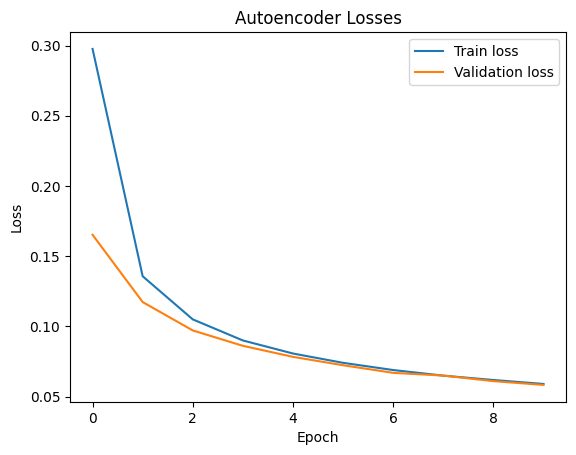

In [18]:
ae = Autoencoder(m_cfg['input_channels'], m_cfg['input_size']).to(device)
print(f"Training Autoencoder on {dataset_name}")
ae = train_autoencoder(ae, train_loader, val_loader, device, m_cfg['ae_epochs'], dataset_name)

In [19]:
ae_test_loss = evaluate(ae, test_loader, device, criterion = nn.MSELoss())
print(f'Test Loss: {ae_test_loss:.4f}')

Test Loss: 0.0572


c:\Users\gal19\anaconda3\envs\cs236781-hw\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



Training Classifier on MNIST


CLS Epoch 1: 100%|██████████| 391/391 [00:01<00:00, 228.83it/s]


CLS Epoch [1/20] Train Loss: 0.2860, Train Acc: 91.19%, Val Loss: 0.1250, Val Acc: 96.14%


CLS Epoch 2: 100%|██████████| 391/391 [00:01<00:00, 259.55it/s]


...

CLS Epoch [18/20] Train Loss: 0.0440, Train Acc: 98.54%, Val Loss: 0.0582, Val Acc: 98.26%


CLS Epoch 19: 100%|██████████| 391/391 [00:01<00:00, 266.73it/s]


CLS Epoch [19/20] Train Loss: 0.0439, Train Acc: 98.56%, Val Loss: 0.0560, Val Acc: 98.44%


CLS Epoch 20: 100%|██████████| 391/391 [00:01<00:00, 265.35it/s]


CLS Epoch [20/20] Train Loss: 0.0414, Train Acc: 98.67%, Val Loss: 0.0566, Val Acc: 98.46%


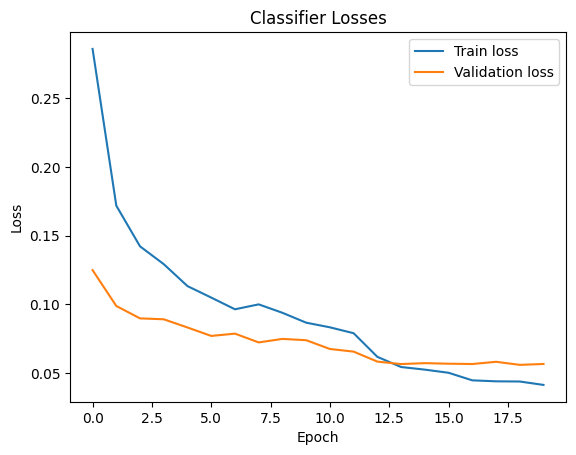

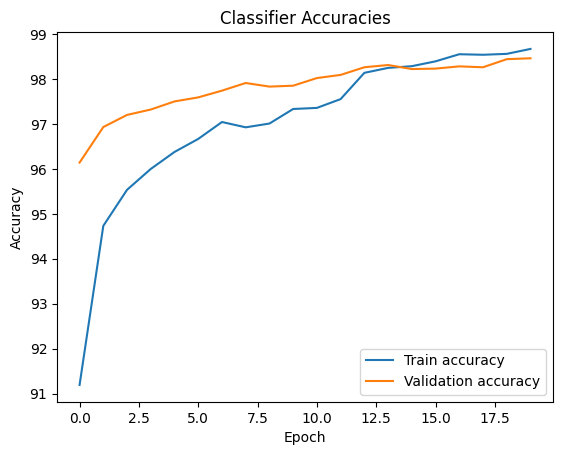

In [20]:
# Classifier

classifier = Classifier(ae.encoder, m_cfg['input_channels'], m_cfg['input_size'], m_cfg['num_classes']).to(device)

for param in classifier.encoder.parameters():
    param.requires_grad = False
print(f"\nTraining Classifier on {dataset_name}")
classifier = train_classifier(classifier, train_loader, val_loader, device, m_cfg['cls_epochs'], dataset_name)

In [21]:

# Final test
test_acc = evaluate_classifier(classifier, test_loader, device)
print(f'\nFinal Test Accuracy on {dataset_name}: {test_acc:.2f}%')




Final Test Accuracy on MNIST: 98.52%


In [18]:
# Visualization
import importlib
import utils
importlib.reload(utils)
from utils import plot_tsne
plot_tsne(ae.encoder, test_loader, device)

Mean Reconstruction Error: 0.057509


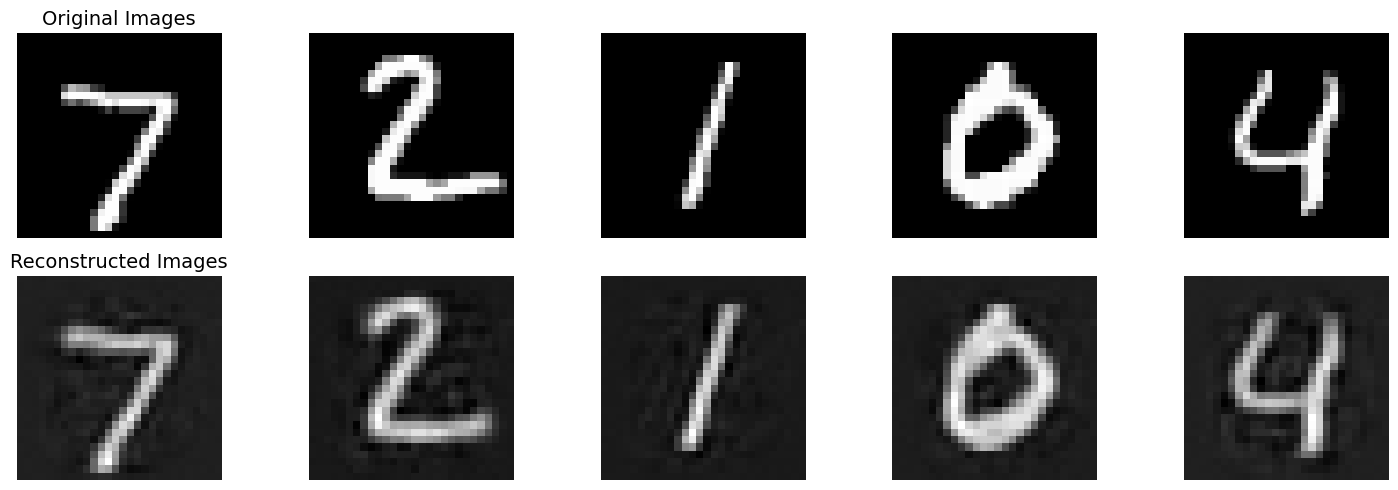

In [22]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

def plot_reconstructions_with_error(model, dataloader, device, num_images=5):
    model.eval()
    images, reconstructions = [], []
    reconstruction_errors = []
    
    with torch.no_grad():
        for data in dataloader:
            img, _ = data
            img = img.to(device)
            recon = model(img)
            images.append(img.cpu())
            reconstructions.append(recon.cpu())
            # Compute reconstruction error (MSE) for the batch
            error = F.mse_loss(recon, img, reduction='none').view(img.size(0), -1).mean(dim=1)
            reconstruction_errors.extend(error.cpu().numpy())
            if len(images) >= num_images:
                break
    
    images = torch.cat(images)[:num_images]
    reconstructions = torch.cat(reconstructions)[:num_images]
    
    # Compute mean reconstruction error
    mean_error = sum(reconstruction_errors) / len(reconstruction_errors)
    print(f"Mean Reconstruction Error: {mean_error:.6f}")
    
    # Plot original and reconstructed images
    fig, axes = plt.subplots(2, num_images, figsize=(15, 5))
    for i in range(num_images):
        axes[0, i].imshow(images[i].permute(1, 2, 0).squeeze(), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(reconstructions[i].permute(1, 2, 0).squeeze(), cmap='gray')
        axes[1, i].axis('off')
    
    axes[0, 0].set_title('Original Images', size=14)
    axes[1, 0].set_title('Reconstructed Images', size=14)
    plt.tight_layout()
    plt.show()

# Assuming `ae` is your autoencoder model and `test_loader` is your test dataloader
plot_reconstructions_with_error(ae, test_loader, device)

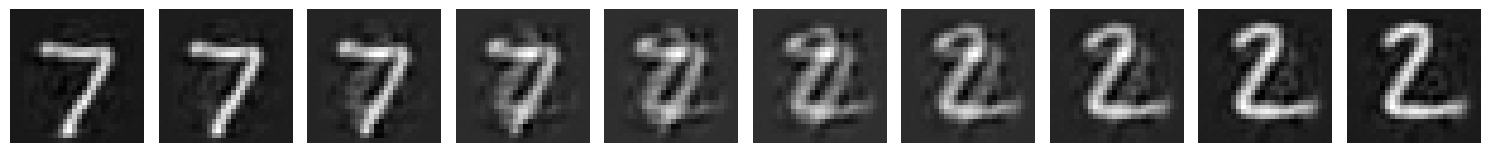

In [29]:
def linear_interpolation(model, dataloader, device, num_steps=10):
    model.eval()
    images, labels = next(iter(dataloader))
    img1, img2 = images[0].to(device), images[1].to(device)
    
    # Flatten the images for the encoder
    img1_flat = img1.unsqueeze(0).view(-1, model.input_dim)
    img2_flat = img2.unsqueeze(0).view(-1, model.input_dim)
    
    with torch.no_grad():
        latent1 = model.encoder(img1_flat)
        latent2 = model.encoder(img2_flat)
    
    interpolations = []
    for alpha in np.linspace(0, 1, num_steps):
        latent_interp = (1 - alpha) * latent1 + alpha * latent2
        with torch.no_grad():
            recon_interp = model.decoder(latent_interp).view(-1, model.input_channels, model.input_size, model.input_size)
        interpolations.append(recon_interp.cpu().squeeze(0))
    
    fig, axes = plt.subplots(1, num_steps, figsize=(15, 5))
    for i, interp in enumerate(interpolations):
        axes[i].imshow(interp.permute(1, 2, 0).squeeze(), cmap='gray')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Assuming `ae` is your autoencoder model and `test_loader` is your test dataloader
linear_interpolation(ae, test_loader, device)

In [ ]:
####################################

In [12]:
# now for CIFAR10
set_seed(42)
dataset_name = "CIFAR10"
cfg = config[dataset_name]
train_dataset, val_dataset, test_dataset = load_dataset(dataset_name)
train_loader, val_loader, test_loader = create_data_loaders(train_dataset, val_dataset, test_dataset, batch_size)


Training Autoencoder on CIFAR10


AE Epoch 1: 100%|██████████| 313/313 [00:01<00:00, 278.59it/s]


AE Epoch [1/30] Train Loss: 0.0869, Val Loss: 0.0596


AE Epoch 2: 100%|██████████| 313/313 [00:00<00:00, 326.31it/s]


AE Epoch [2/30] Train Loss: 0.0527, Val Loss: 0.0484


...

AE Epoch [28/30] Train Loss: 0.0250, Val Loss: 0.0258


AE Epoch 29: 100%|██████████| 313/313 [00:00<00:00, 339.93it/s]


AE Epoch [29/30] Train Loss: 0.0248, Val Loss: 0.0258


AE Epoch 30: 100%|██████████| 313/313 [00:00<00:00, 326.52it/s]


AE Epoch [30/30] Train Loss: 0.0248, Val Loss: 0.0248


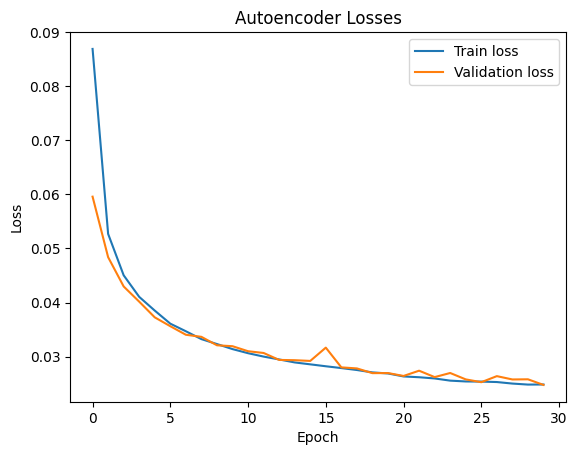

Model saved to use_cifar_autoencoder.pth


In [13]:
import os
import torch

# Define the file path
model_path = "use_cifar_autoencoder.pth"

# Initialize the autoencoder model
ae = Autoencoder(c_cfg['input_channels'], c_cfg['input_size']).to(device)
print(f"Training Autoencoder on {dataset_name}")
ae = train_autoencoder(ae, train_loader, val_loader, device, c_cfg['ae_epochs'], dataset_name)
# Save the trained model
torch.save(ae.state_dict(), model_path)
print(f"Model saved to {model_path}")

In [14]:
ae_test_loss = evaluate(ae, test_loader, device, criterion = nn.MSELoss())
print(f'Test Loss: {ae_test_loss:.4f}')

Test Loss: 0.0246



Training Classifier on CIFAR10


CLS Epoch 1: 100%|██████████| 313/313 [00:13<00:00, 23.11it/s]


CLS Epoch [1/25] Train Loss: 1.8113, Train Acc: 36.55%, Val Loss: 1.5322, Val Acc: 44.93%


CLS Epoch 2: 100%|██████████| 313/313 [00:13<00:00, 23.55it/s]


CLS Epoch [2/25] Train Loss: 1.6421, Train Acc: 41.50%, Val Loss: 1.4701, Val Acc: 46.80%


...

CLS Epoch [23/25] Train Loss: 1.1124, Train Acc: 60.21%, Val Loss: 1.1790, Val Acc: 58.73%
Epoch    23: reducing learning rate of group 0 to 2.5000e-04.


CLS Epoch 24: 100%|██████████| 313/313 [00:13<00:00, 23.02it/s]


CLS Epoch [24/25] Train Loss: 1.0766, Train Acc: 61.10%, Val Loss: 1.1749, Val Acc: 58.89%


CLS Epoch 25: 100%|██████████| 313/313 [00:13<00:00, 23.29it/s]


CLS Epoch [25/25] Train Loss: 1.0667, Train Acc: 62.15%, Val Loss: 1.1676, Val Acc: 58.97%


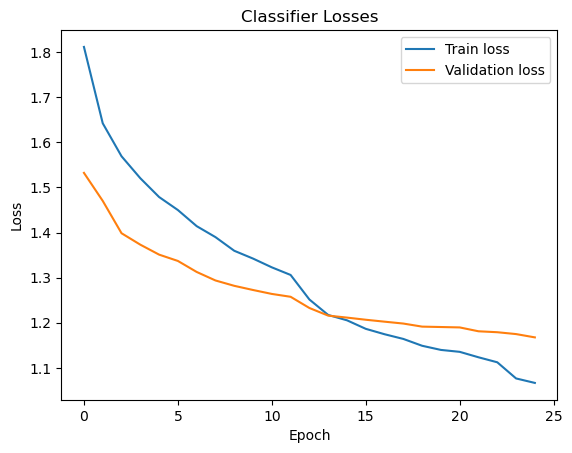

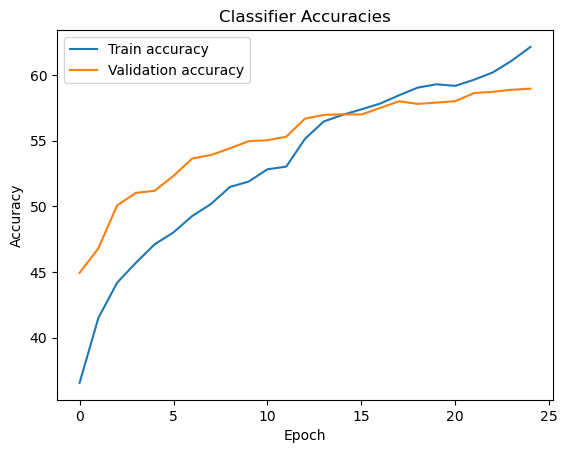

In [ ]:
# model_path = "use_cifar_autoencoder.pth"
# ae = Autoencoder(c_cfg['input_channels'], c_cfg['input_size']).to(device)
# ae.load_state_dict(torch.load(model_path))
# ae.eval()

# Classifier
classifier = Classifier(ae.encoder, c_cfg['input_channels'], c_cfg['input_size'], c_cfg['num_classes']).to(device)

for param in classifier.encoder.parameters():
    param.requires_grad = False
print(f"\nTraining Classifier on {dataset_name}")
classifier = train_classifier(classifier, train_loader, val_loader, device, c_cfg['cls_epochs'], dataset_name)


In [18]:
# Final test
test_acc = evaluate_classifier(classifier, test_loader, device)
print(f'\nFinal Test Accuracy on {dataset_name}: {test_acc:.2f}%')


Final Test Accuracy on CIFAR10: 58.05%


In [13]:
# Visualization
plot_tsne(ae.encoder, test_loader, device)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8980392..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.87198615..0.88067853].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9372549].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1774783..1.051702].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9764706..0.9764706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.91070646..0.99503237].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7411765..0.8352

Mean Reconstruction Error: 0.024570


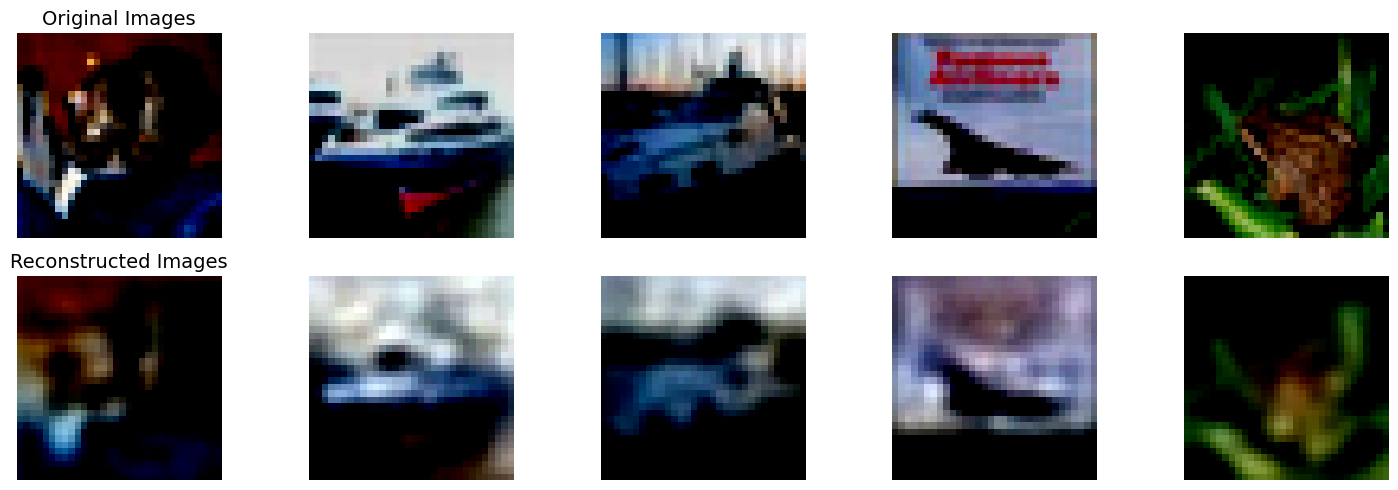

In [15]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

def plot_reconstructions_with_error(model, dataloader, device, num_images=5):
    model.eval()
    images, reconstructions = [], []
    reconstruction_errors = []
    
    with torch.no_grad():
        for data in dataloader:
            img, _ = data
            img = img.to(device)
            recon = model(img)
            images.append(img.cpu())
            reconstructions.append(recon.cpu())
            # Compute reconstruction error (MSE) for the batch
            error = F.mse_loss(recon, img, reduction='none').view(img.size(0), -1).mean(dim=1)
            reconstruction_errors.extend(error.cpu().numpy())
            if len(images) >= num_images:
                break
    
    images = torch.cat(images)[:num_images]
    reconstructions = torch.cat(reconstructions)[:num_images]
    
    # Compute mean reconstruction error
    mean_error = sum(reconstruction_errors) / len(reconstruction_errors)
    print(f"Mean Reconstruction Error: {mean_error:.6f}")
    
    # Plot original and reconstructed images
    fig, axes = plt.subplots(2, num_images, figsize=(15, 5))
    for i in range(num_images):
        axes[0, i].imshow(images[i].permute(1, 2, 0).squeeze(), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(reconstructions[i].permute(1, 2, 0).squeeze(), cmap='gray')
        axes[1, i].axis('off')
    
    axes[0, 0].set_title('Original Images', size=14)
    axes[1, 0].set_title('Reconstructed Images', size=14)
    plt.tight_layout()
    plt.show()

# Assuming `ae` is your autoencoder model and `test_loader` is your test dataloader
plot_reconstructions_with_error(ae, test_loader, device)

In [ ]:
###############################################